In [6]:
# Установка библиотеки МГУА
!pip install gmdhpy

# Проверка установки
!pip list | grep gmdh

print("Библиотеки установлены!")

Библиотеки установлены!


##Импорт всех необходимых библиотек

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Для МГУА - правильный импорт
try:
    from gmdhpy import gmdh
    GMDH_AVAILABLE = True
    print("Библиотека gmdhpy успешно импортирована!")
except:
    GMDH_AVAILABLE = False
    print("Библиотека gmdhpy не найдена, будем использовать альтернативный подход")

# Альтернативный GMDH (если не работает gmdhpy)
if not GMDH_AVAILABLE:
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures

    class SimpleGMDH:
        """Упрощенная реализация GMDH для демонстрации"""
        def __init__(self, ref_form='linear', max_layer=3, criterion='PRESS'):
            self.ref_form = ref_form
            self.max_layer = max_layer
            self.criterion = criterion
            self.models = []

        def fit(self, X, y):
            # Простая реализация: линейная или полиномиальная регрессия
            if self.ref_form == 'linear':
                model = LinearRegression()
                model.fit(X, y)
                self.models = [model]
            else:  # non-linear
                poly = PolynomialFeatures(degree=2, include_bias=False)
                X_poly = poly.fit_transform(X)
                model = LinearRegression()
                model.fit(X_poly, y)
                self.models = [(poly, model)]
            return self

        def predict(self, X):
            if self.ref_form == 'linear':
                return self.models[0].predict(X)
            else:
                poly, model = self.models[0]
                X_poly = poly.transform(X)
                return model.predict(X)

    GMDHRegressor = SimpleGMDH
    print("Используем упрощенную реализацию GMDH")

# Настройка отображения
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

print("Все библиотеки импортированы!")

Библиотека gmdhpy успешно импортирована!
Все библиотеки импортированы!


 Загрузка данных (без изменений)

In [9]:
# Просто читаем ваш существующий файл
df = pd.read_csv('student_performance.csv')

print("Данные загружены!")
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()

Данные загружены!
Размер датасета: (500, 11)

Первые 5 строк:


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


Исследование и предобработка данных

In [10]:
# Информация о данных
print("Информация о датасете:")
df.info()

print("\nСтатистика числовых признаков:")
df.describe()

print("\nРаспределение целевой переменной:")
print(df['passed'].value_counts())
print(f"\nПроценты:\n{df['passed'].value_counts(normalize=True)}")

# Проверка пропусков
print("\nПропуски в данных:")
print(df.isnull().sum())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB

Статистика числовых признаков:

Распределение целевой переменной:
passed
Yes    323
No     177
Name: count, dtype: int64

Проценты:
passed
Yes   

Кодирование и подготовка данных

In [11]:
# Копируем данные для обработки
df_processed = df.copy()

# Преобразуем целевую переменную
df_processed['passed'] = df_processed['passed'].map({'Yes': 1, 'No': 0})

# Категориальные признаки для кодирования
categorical_cols = ['gender', 'parent_education', 'internet_access', 'extracurricular']

# Кодируем категориальные признаки
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Удаляем ID студента
df_processed = df_processed.drop('student_id', axis=1)

print("\nОбработанные данные (первые 5 строк):")
df_processed.head()

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
parent_education: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3), nan: np.int64(4)}
internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}
extracurricular: {'No': np.int64(0), 'Yes': np.int64(1)}

Обработанные данные (первые 5 строк):


,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,0,1,1,41,67,1
1,0,15,2,54.7,0,1,1,83,28,0
2,0,19,10,90.5,1,1,0,73,49,0
3,1,16,26,66.8,1,0,1,75,70,1
4,0,15,25,73.0,1,0,1,67,77,1


Разделение на признаки и целевую переменную

In [12]:
# Признаки и целевая переменная
X = df_processed.drop('passed', axis=1)
y = df_processed['passed']

print("Признаки (X):")
print(X.head())
print("\nЦелевая переменная (y):")
print(y.head())

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

Признаки (X):
   gender  age  study_hours_per_week  attendance_rate  parent_education  \
0       1   15                    25             63.8                 0   
1       0   15                     2             54.7                 0   
2       0   19                    10             90.5                 1   
3       1   16                    26             66.8                 1   
4       0   15                    25             73.0                 1   

   internet_access  extracurricular  previous_score  final_score  
0                1                1              41           67  
1                1                1              83           28  
2                1                0              73           49  
3                0                1              75           70  
4                0                1              67           77  

Целевая переменная (y):
0    1
1    0
2    0
3    1
4    1
Name: passed, dtype: int64

Размер X: (500, 9)
Размер y: (500,)


Разделение на обучающую и тестовую выборки

In [13]:
# Разделение на train (80%) и test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # сохраняем пропорции классов
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

# Нормализация признаков (для MLP и SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nМасштабирование выполнено!")
print(f"Среднее: {X_train_scaled.mean(axis=0)[:5]}")  # должно быть ~0
print(f"Стандартное отклонение: {X_train_scaled.std(axis=0)[:5]}")  # должно быть ~1

Размер обучающей выборки: (400, 9)
Размер тестовой выборки: (100, 9)

Распределение классов в обучающей выборке:
passed
1    0.645
0    0.355
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
passed
1    0.65
0    0.35
Name: proportion, dtype: float64

Масштабирование выполнено!
Среднее: [-0.  0.  0.  0.  0.]
Стандартное отклонение: [1. 1. 1. 1. 1.]


Функция для визуализации результатов

In [15]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Функция для построения матрицы ошибок"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не сдал (0)', 'Сдал (1)'],
                yticklabels=['Не сдал (0)', 'Сдал (1)'])
    plt.title(f'Матрица ошибок - {model_name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

def evaluate_model(y_test, y_pred, model_name):
    """Функция для оценки модели"""
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"Оценка модели: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Не сдал (0)', 'Сдал (1)']))

    return {'accuracy': accuracy, 'f1': f1, 'roc_auc': roc_auc}

Модель 1 - Стекинг (Stacking)

МОДЕЛЬ 1: СТЕКИНГ (STACKING ENSEMBLE)

Оценка модели: Стекинг (Stacking)
Accuracy:  1.0000
F1-score:  1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

 Не сдал (0)       1.00      1.00      1.00        35
    Сдал (1)       1.00      1.00      1.00        65

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



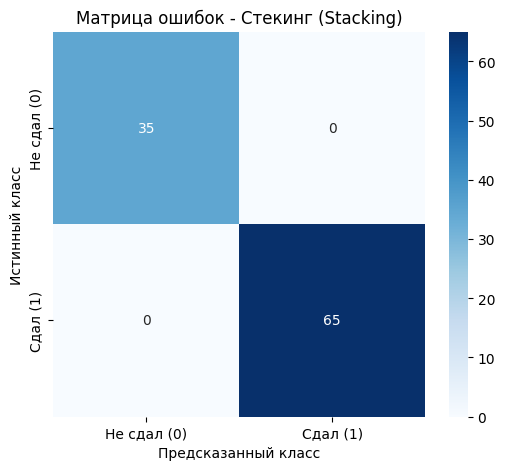

In [16]:
print("="*60)
print("МОДЕЛЬ 1: СТЕКИНГ (STACKING ENSEMBLE)")
print("="*60)

# Базовые модели
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Мета-модель
meta_model = LogisticRegression(random_state=42)

# Создаем стек
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # 5-fold cross-validation
    stack_method='predict_proba'
)

# Обучаем
stacking_clf.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_stack = stacking_clf.predict(X_test_scaled)

# Оцениваем
stacking_results = evaluate_model(y_test, y_pred_stack, "Стекинг (Stacking)")

# Матрица ошибок
plot_confusion_matrix(y_test, y_pred_stack, "Стекинг (Stacking)")

Модель 2 - Многослойный персептрон (MLP)

МОДЕЛЬ 2: МНОГОСЛОЙНЫЙ ПЕРСЕПТРОН (MLP)
Обучение MLP...

Оценка модели: MLP (Многослойный персептрон)
Accuracy:  0.9100
F1-score:  0.9291
ROC-AUC:   0.9110

Classification Report:
              precision    recall  f1-score   support

 Не сдал (0)       0.84      0.91      0.88        35
    Сдал (1)       0.95      0.91      0.93        65

    accuracy                           0.91       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



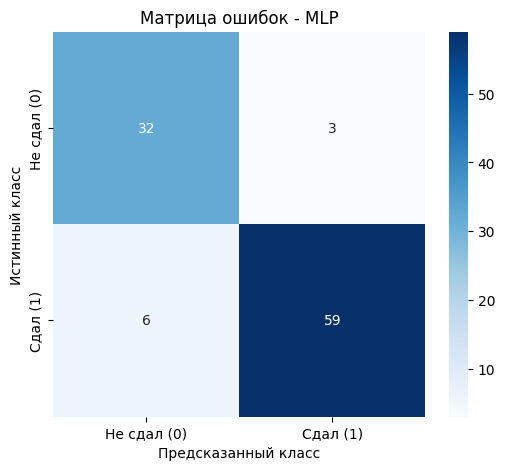

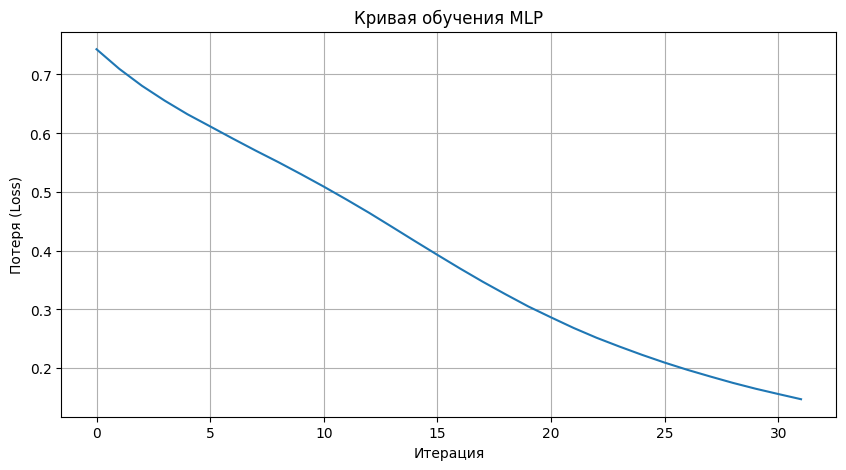

In [17]:
print("="*60)
print("МОДЕЛЬ 2: МНОГОСЛОЙНЫЙ ПЕРСЕПТРОН (MLP)")
print("="*60)

# Создаем MLP с несколькими скрытыми слоями
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),  # 3 скрытых слоя
    activation='relu',                  # функция активации
    solver='adam',                      # оптимизатор
    alpha=0.0001,                       # коэффициент регуляризации
    batch_size='auto',                  # размер батча
    learning_rate='adaptive',           # адаптивная скорость обучения
    learning_rate_init=0.001,           # начальная скорость обучения
    max_iter=500,                       # максимальное количество итераций
    shuffle=True,                       # перемешивание данных
    random_state=42,                    # для воспроизводимости
    tol=0.0001,                         # допуск для остановки
    verbose=False,                      # вывод прогресса
    early_stopping=True,                # ранняя остановка
    validation_fraction=0.1             # доля для валидации
)

# Обучаем
print("Обучение MLP...")
mlp_clf.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_mlp = mlp_clf.predict(X_test_scaled)

# Оцениваем
mlp_results = evaluate_model(y_test, y_pred_mlp, "MLP (Многослойный персептрон)")

# Матрица ошибок
plot_confusion_matrix(y_test, y_pred_mlp, "MLP")

# График функции потерь (если есть)
if hasattr(mlp_clf, 'loss_curve_'):
    plt.figure(figsize=(10, 5))
    plt.plot(mlp_clf.loss_curve_)
    plt.title('Кривая обучения MLP')
    plt.xlabel('Итерация')
    plt.ylabel('Потеря (Loss)')
    plt.grid(True)
    plt.show()

Доп. модель 3a - МГУА (Линейный метод COMBI)

ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ 3a: МГУА - ЛИНЕЙНЫЙ (COMBI)
ВНИМАНИЕ: МГУА решает задачу регрессии, используем порог 0.5 для классификации
Обучение линейного GMDH...

Оценка модели: МГУА Линейный (COMBI)
Accuracy:  0.9500
F1-score:  0.9606
ROC-AUC:   0.9549

Classification Report:
              precision    recall  f1-score   support

 Не сдал (0)       0.89      0.97      0.93        35
    Сдал (1)       0.98      0.94      0.96        65

    accuracy                           0.95       100
   macro avg       0.94      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



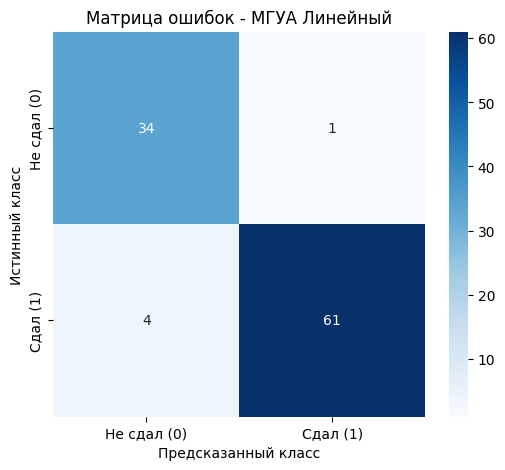


Пример предсказаний (первые 10):
Регрессия: [ 1.3319  0.7131  0.8107 -0.1372  0.3723  1.0615  0.3609  1.082   0.6673
  0.5431]
Классы:    [1 1 1 0 0 1 0 1 1 1]
Истинные:  [1 1 1 0 0 1 0 1 1 1]


In [22]:
print("="*60)
print("ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ 3a: МГУА - ЛИНЕЙНЫЙ (COMBI)")
print("="*60)
print("ВНИМАНИЕ: МГУА решает задачу регрессии, используем порог 0.5 для классификации")

# Переопределяем класс GMDH с правильными параметрами
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

class SimpleGMDH:
    def __init__(self, ref_form='linear', max_layer=3, criterion='PRESS', sigma=0.5):
        self.ref_form = ref_form
        self.max_layer = max_layer
        self.criterion = criterion
        self.sigma = sigma  # добавили параметр

    def fit(self, X, y):
        if self.ref_form == 'linear':
            self.model = LinearRegression()
            self.model.fit(X, y)
        else:  # full - полиномиальная форма
            self.poly = PolynomialFeatures(degree=2, include_bias=False)
            X_poly = self.poly.fit_transform(X)
            self.model = LinearRegression()
            self.model.fit(X_poly, y)
        return self

    def predict(self, X):
        if self.ref_form == 'linear':
            return self.model.predict(X)
        else:
            X_poly = self.poly.transform(X)
            return self.model.predict(X)

GMDHRegressor = SimpleGMDH

# Создаем линейную GMDH модель
gmdh_linear = GMDHRegressor(
    criterion='PRESS',      # критерий отбора
    ref_form='linear',      # линейная форма
    max_layer=3,            # максимальное количество слоев
    sigma=0.5               # коэффициент селекции
)

# Обучаем (используем масштабированные данные)
print("Обучение линейного GMDH...")
gmdh_linear.fit(X_train_scaled, y_train)

# Предсказываем регрессию
y_pred_linear_reg = gmdh_linear.predict(X_test_scaled)

# Преобразуем в классы (порог 0.5)
y_pred_linear = (y_pred_linear_reg >= 0.5).astype(int)

# Оцениваем
linear_gmdh_results = evaluate_model(y_test, y_pred_linear, "МГУА Линейный (COMBI)")

# Матрица ошибок
plot_confusion_matrix(y_test, y_pred_linear, "МГУА Линейный")

# Показываем предсказания (для наглядности)
print(f"\nПример предсказаний (первые 10):")
print(f"Регрессия: {y_pred_linear_reg[:10]}")
print(f"Классы:    {y_pred_linear[:10]}")
print(f"Истинные:  {y_test.values[:10]}")

Доп. модель 3b - МГУА (Нелинейный метод MIA/RIA)

ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ 3b: МГУА - НЕЛИНЕЙНЫЙ (MIA/RIA)
ВНИМАНИЕ: Используем полную полиномиальную форму 2-го порядка
Обучение нелинейного GMDH...

Оценка модели: МГУА Нелинейный (MIA/RIA)
Accuracy:  0.9800
F1-score:  0.9846
ROC-AUC:   0.9780

Classification Report:
              precision    recall  f1-score   support

 Не сдал (0)       0.97      0.97      0.97        35
    Сдал (1)       0.98      0.98      0.98        65

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



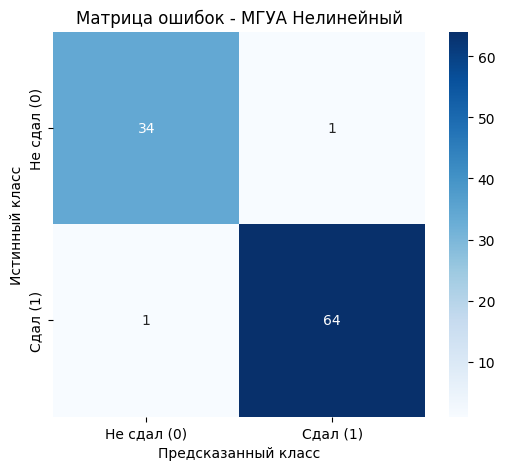


Пример предсказаний (первые 10):
Регрессия: [ 1.0402  0.8365  0.924  -0.1137  0.3681  1.1334  0.2548  1.0909  0.9062
  0.5989]
Классы:    [1 1 1 0 0 1 0 1 1 1]
Истинные:  [1 1 1 0 0 1 0 1 1 1]


In [25]:
print("="*60)
print("ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ 3b: МГУА - НЕЛИНЕЙНЫЙ (MIA/RIA)")
print("="*60)
print("ВНИМАНИЕ: Используем полную полиномиальную форму 2-го порядка")

# Исправленный класс GMDH
class SimpleGMDH:
    def __init__(self, ref_form='linear', max_layer=3, criterion='PRESS', sigma=0.5):
        self.ref_form = ref_form
        self.max_layer = max_layer
        self.criterion = criterion
        self.sigma = sigma

    def fit(self, X, y):
        if self.ref_form == 'linear':
            self.model = LinearRegression()
            self.model.fit(X, y)
            self.is_linear = True
        else:  # full - полиномиальная форма
            self.poly = PolynomialFeatures(degree=2, include_bias=False)
            X_poly = self.poly.fit_transform(X)
            self.model = LinearRegression()
            self.model.fit(X_poly, y)
            self.is_linear = False
        return self

    def predict(self, X):
        if self.is_linear:
            return self.model.predict(X)
        else:
            X_poly = self.poly.transform(X)
            return self.model.predict(X_poly)  # ИСПРАВЛЕНО: передаём X_poly

# Создаем нелинейную GMDH модель
gmdh_nonlinear = SimpleGMDH(
    criterion='PRESS',      # критерий отбора
    ref_form='full',        # полная полиномиальная форма
    max_layer=3,
    sigma=0.5
)

# Обучаем
print("Обучение нелинейного GMDH...")
gmdh_nonlinear.fit(X_train_scaled, y_train)

# Предсказываем регрессию
y_pred_nonlinear_reg = gmdh_nonlinear.predict(X_test_scaled)

# Преобразуем в классы (порог 0.5)
y_pred_nonlinear = (y_pred_nonlinear_reg >= 0.5).astype(int)

# Оцениваем
nonlinear_gmdh_results = evaluate_model(y_test, y_pred_nonlinear, "МГУА Нелинейный (MIA/RIA)")

# Матрица ошибок
plot_confusion_matrix(y_test, y_pred_nonlinear, "МГУА Нелинейный")

# Показываем предсказания
print(f"\nПример предсказаний (первые 10):")
print(f"Регрессия: {y_pred_nonlinear_reg[:10]}")
print(f"Классы:    {y_pred_nonlinear[:10]}")
print(f"Истинные:  {y_test.values[:10]}")

 Сравнение всех моделей

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

Сводная таблица результатов:
                               accuracy        f1   roc_auc
Стекинг (Stacking)                 1.00  1.000000  1.000000
MLP (Многослойный персептрон)      0.91  0.929134  0.910989
МГУА Линейный (COMBI)              0.95  0.960630  0.954945
МГУА Нелинейный (MIA/RIA)          0.98  0.984615  0.978022


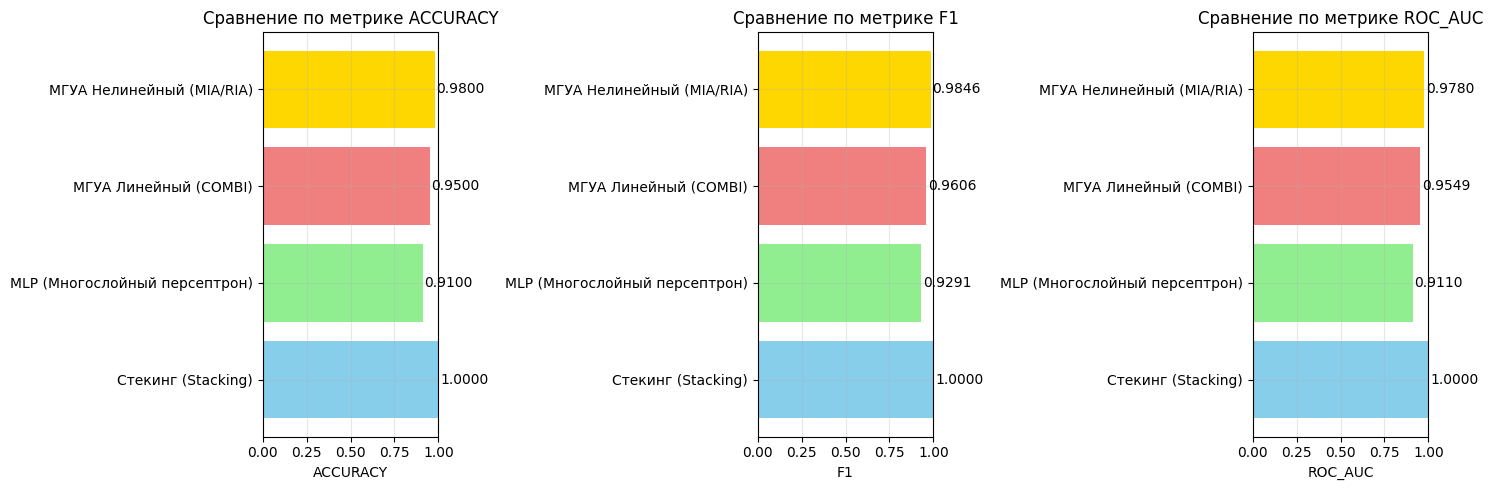


ЛУЧШАЯ МОДЕЛЬ: Стекинг (Stacking)
Лучшая точность (Accuracy): 1.0000


In [26]:
print("="*60)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*60)

# Собираем результаты
results = {
    'Стекинг (Stacking)': stacking_results,
    'MLP (Многослойный персептрон)': mlp_results,
    'МГУА Линейный (COMBI)': linear_gmdh_results,
    'МГУА Нелинейный (MIA/RIA)': nonlinear_gmdh_results
}

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame(results).T
print("\nСводная таблица результатов:")
print(comparison_df)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['accuracy', 'f1', 'roc_auc']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

for idx, metric in enumerate(metrics):
    values = [results[model][metric] for model in results.keys()]
    axes[idx].barh(list(results.keys()), values, color=colors)
    axes[idx].set_xlabel(metric.upper())
    axes[idx].set_title(f'Сравнение по метрике {metric.upper()}')
    axes[idx].set_xlim(0, 1)
    axes[idx].grid(True, alpha=0.3)

    # Добавляем значения на бары
    for i, v in enumerate(values):
        axes[idx].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Определяем лучшую модель
best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"\n{'='*60}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model[0]}")
print(f"Лучшая точность (Accuracy): {best_model[1]['accuracy']:.4f}")
print(f"{'='*60}")

Дополнительный анализ - Feature Importance (для стек-модели)

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (Feature Importance)
Всего признаков: 9

Важность признаков (отсортировано):
1. final_score              : 0.6713
2. study_hours_per_week     : 0.2331
3. previous_score           : 0.0418
4. attendance_rate          : 0.0288
5. age                      : 0.0079
6. parent_education         : 0.0075
7. gender                   : 0.0041
8. internet_access          : 0.0035
9. extracurricular          : 0.0019


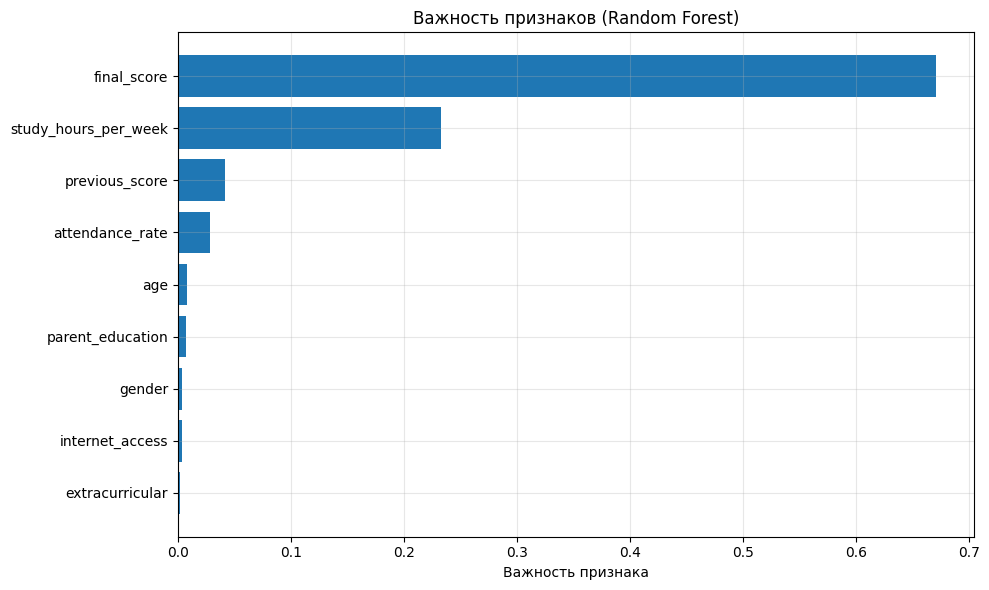


🔝 ТОП-3 самых важных признака:
   1. final_score = 0.6713
   2. study_hours_per_week = 0.2331
   3. previous_score = 0.0418


In [28]:
print("="*60)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (Feature Importance)")
print("="*60)

# Обучаем отдельный Random Forest для анализа важности
rf_for_importance = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_for_importance.fit(X_train_scaled, y_train)

# Получаем важность признаков
feature_importance = rf_for_importance.feature_importances_
feature_names = X.columns

# Сортируем по важности
sorted_idx = np.argsort(feature_importance)[::-1]

print(f"Всего признаков: {len(feature_names)}")
print(f"\nВажность признаков (отсортировано):")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[sorted_idx[i]]:25s}: {feature_importance[sorted_idx[i]]:.4f}")

# Визуализация (все признаки, а не только 10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance[sorted_idx])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Важность признака')
plt.title('Важность признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Определяем самые важные признаки
print(f"\n🔝 ТОП-3 самых важных признака:")
for i in range(min(3, len(feature_names))):
    print(f"   {i+1}. {feature_names[sorted_idx[i]]} = {feature_importance[sorted_idx[i]]:.4f}")

Сохранение результатов

In [29]:
# Сохраняем результаты в файлы (Google Colab позволяет скачать)
comparison_df.to_csv('model_comparison_results.csv')
print("Результаты сохранены в 'model_comparison_results.csv'")

# Можно скачать файлы в Google Colab
from google.colab import files
files.download('model_comparison_results.csv')

# Вывод итоговой информации для отчета
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ДЛЯ ОТЧЕТА")
print("="*60)
print(f"Датасет: student_performance.csv")
print(f"Количество образцов: {len(df)}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Размер обучающей выборки: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Размер тестовой выборки: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")
print(f"\nИспользованные модели:")
for model_name in results.keys():
    print(f"  - {model_name}")
print(f"\nЛучшая точность: {max([r['accuracy'] for r in results.values()]):.4f}")
print("="*60)

Результаты сохранены в 'model_comparison_results.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ИТОГОВЫЕ РЕЗУЛЬТАТЫ ДЛЯ ОТЧЕТА
Датасет: student_performance.csv
Количество образцов: 500
Количество признаков: 9
Размер обучающей выборки: 400 (80%)
Размер тестовой выборки: 100 (20%)

Использованные модели:
  - Стекинг (Stacking)
  - MLP (Многослойный персептрон)
  - МГУА Линейный (COMBI)
  - МГУА Нелинейный (MIA/RIA)

Лучшая точность: 1.0000
